Random_state:  18
              precision    recall  f1-score   support

    Na_ultra       0.17      0.25      0.20         4
         Not       0.62      0.50      0.56        10

    accuracy                           0.43        14
   macro avg       0.40      0.38      0.38        14
weighted avg       0.49      0.43      0.45        14

Accuracy: 42.857142857142854 %


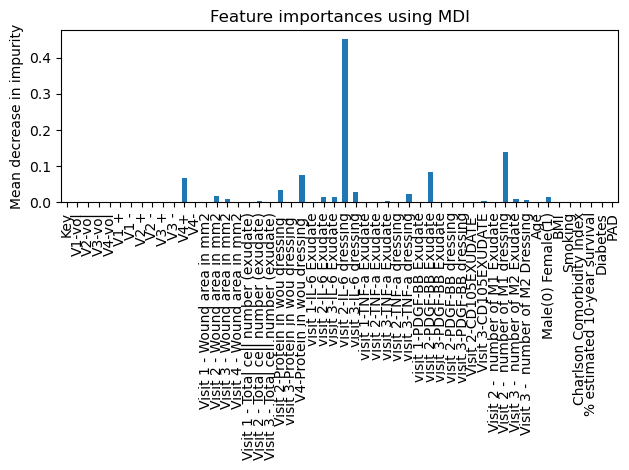

[[-0.26619375  1.2661937 ]
 [ 1.4533194  -0.45331943]
 [ 0.29541606  0.70458394]
 [ 0.6525149   0.34748513]
 [ 0.97714347  0.02285654]
 [-0.28663218  1.2866322 ]
 [ 1.6983037  -0.69830376]
 [ 1.5678067  -0.5678068 ]
 [-2.4302742   3.4302742 ]
 [ 0.03173667  0.9682633 ]
 [-1.4750037   2.4750037 ]
 [-1.551548    2.551548  ]
 [ 2.5441992  -1.5441992 ]
 [-0.48412168  1.4841217 ]]


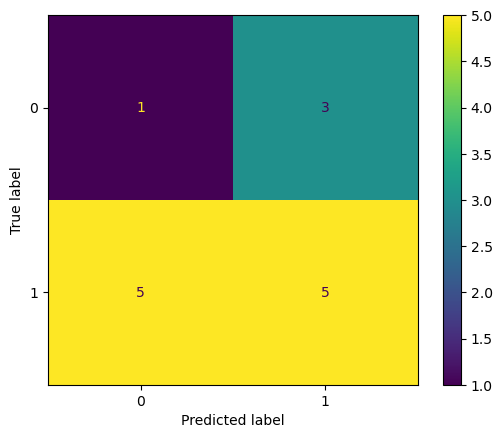

<Figure size 40000x12000 with 0 Axes>

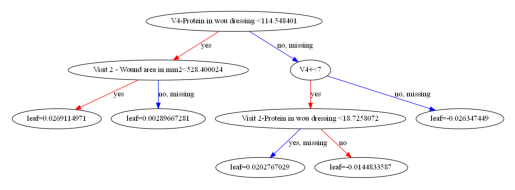

              precision    recall  f1-score   support

    Na_ultra       1.00      1.00      1.00         9
         Not       1.00      1.00      1.00        27

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

--------------------------------------------------------------------------------------------------


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model
from xgboost import *

W_tree=6

Treatment=pd.read_csv("../AD report/NA heal pathway train.csv")
Treatment_test=pd.read_csv("../AD report/NA heal pathway test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]



#y_train = to_categorical(y_train)
#y_test = to_categorical(y_test)




R_state=random.randrange(1,100)
print("Random_state: ",R_state)
#R_state=45




           
    
clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="hist",
                    objective="rank:pairwise",
                  eta=1,
                  max_depth=4,
                  #subsample=0.6,
                 # colsample_bytree=0.8,
                 # colsample_bylevel=0.9,
                 #colsample_bynode=0.7,
                  #reg_lambda=0.6,
                  #reg_alpha=0.7,
                  #rate_drop=1,
                 # skip_drop=0.6,
                  #one_drop=1,
                    random_state=R_state,
                  max_bin=2056,
                num_parallel_tree=25,
  
                  sample_type="weighted",
                
                  
                  
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test, iteration_range=(0, 100))
y_pred = (y_pred > 0.5) 


class_names=["Na_ultra","Not"]

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names
importances = clf.feature_importances_

forest_importances = pd.Series(importances, index=names)
#forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()

y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))

print("--------------------------------------------------------------------------------------------------")

target = 'key'



from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    y_test, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)

